In [92]:
import numpy as np
import pandas as pd


In [93]:
df = pd.read_csv("BIKE DETAILS.csv")

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   str    
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   str    
 4   owner              1061 non-null   str    
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), str(3)
memory usage: 58.2 KB


In [95]:
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [96]:
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

In [97]:
df.sample(15)

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
172,Bajaj Discover 150,25000,2014,Individual,2nd owner,71000,54299.0
617,Bajaj Discover 125,15000,2011,Individual,1st owner,47000,57549.0
237,Honda Aviator,14000,2008,Individual,1st owner,66000,59183.0
17,Yamaha YZF R15 S,40000,2010,Individual,2nd owner,45000,117926.0
523,Honda CB Hornet 160R,70000,2017,Individual,1st owner,35000,87719.0
717,Bajaj Pulsar RS 200,80000,2015,Individual,1st owner,32000,NaN
609,Bajaj Avenger [2015],65000,2010,Individual,1st owner,20000,75502.0
495,Bajaj Discover 135,12000,2007,Individual,1st owner,60000,NaN
303,Suzuki Access 125,45000,2017,Individual,1st owner,22300,NaN
694,Suzuki Intruder 150,75000,2018,Individual,1st owner,10000,NaN


In [98]:
print(df['seller_type'].unique())

<StringArray>
['Individual', 'Dealer']
Length: 2, dtype: str


In [99]:
print(df['owner'].unique())

<StringArray>
['1st owner', '2nd owner', '3rd owner', '4th owner']
Length: 4, dtype: str


In [100]:
df['brand'] = df['name'].str.split().str[0]
df = df.drop(columns=['name'])

In [101]:
df.head()

,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,brand
0,175000,2019,Individual,1st owner,350,NaN,Royal
1,45000,2017,Individual,1st owner,5650,NaN,Honda
2,150000,2018,Individual,1st owner,12000,148114.0,Royal
3,65000,2015,Individual,1st owner,23000,89643.0,Yamaha
4,20000,2011,Individual,2nd owner,21000,NaN,Yamaha


In [102]:
import matplotlib.pyplot as plt

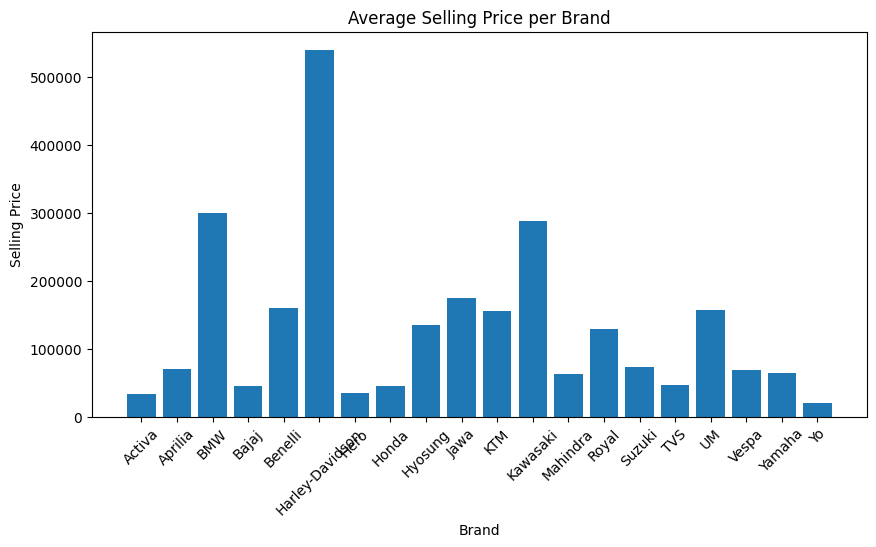

In [103]:
avg_price = df.groupby('brand')['selling_price'].mean()

plt.figure(figsize=(10,5))
plt.bar(avg_price.index, avg_price.values)
plt.xticks(rotation=45)
plt.ylabel('Selling Price')
plt.xlabel('Brand')
plt.title('Average Selling Price per Brand')
plt.show()

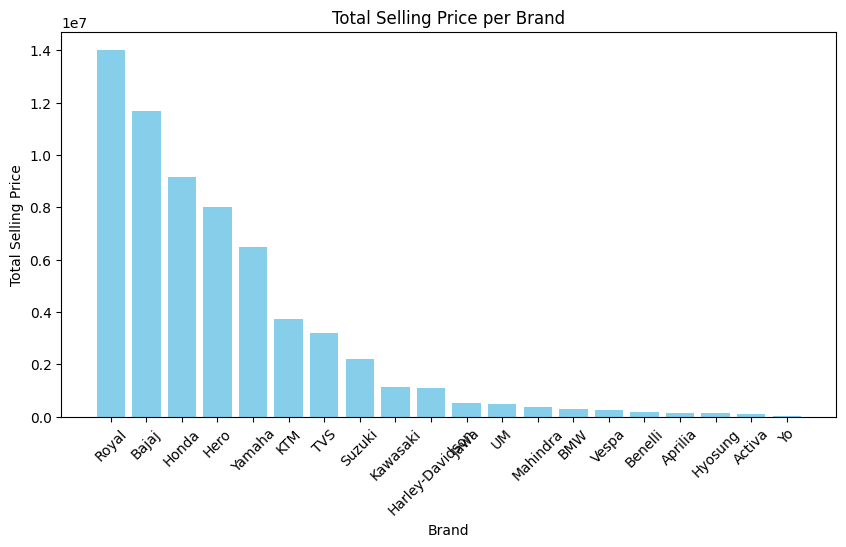

In [104]:
# Total sales per brand
total_sales = df.groupby('brand')['selling_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(total_sales.index, total_sales.values, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Total Selling Price')
plt.xlabel('Brand')
plt.title('Total Selling Price per Brand')
plt.show()

In [105]:
df.shape

(1061, 7)

(array([850., 158.,  40.,   8.,   2.,   1.,   0.,   0.,   0.,   2.]),
 array([  5000.,  80500., 156000., 231500., 307000., 382500., 458000.,
        533500., 609000., 684500., 760000.]),
 <BarContainer object of 10 artists>)

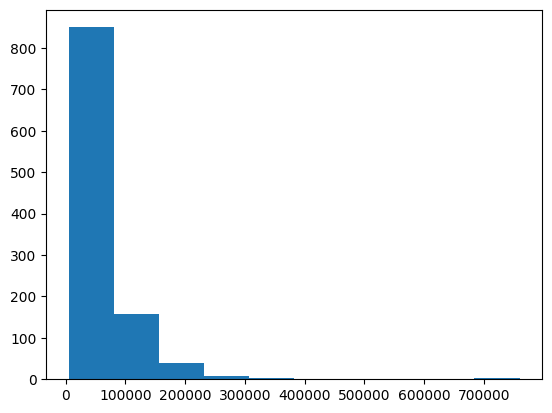

In [106]:
plt.hist(df['selling_price'])

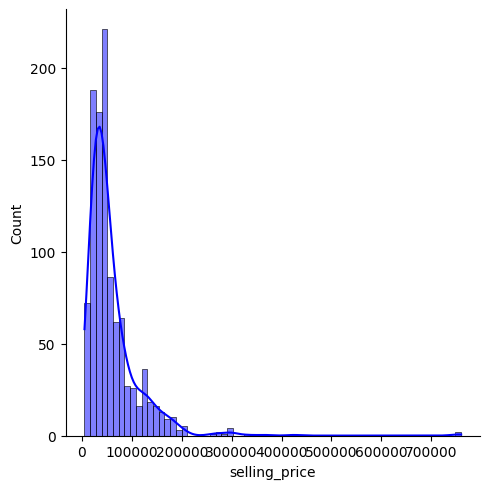

In [107]:
import seaborn as sns
sns.displot(df['selling_price'], kde=True, color='blue')

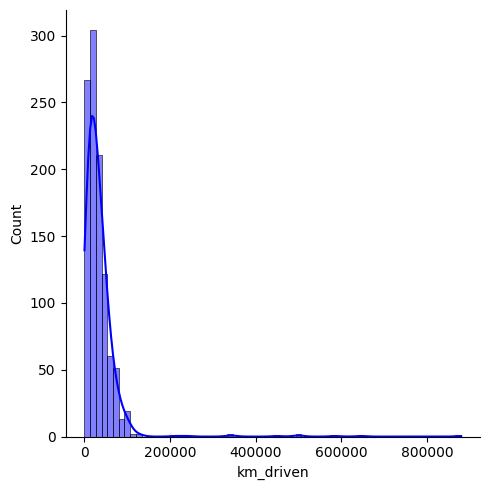

In [108]:
sns.displot(df['km_driven'], kde=True, color='blue')

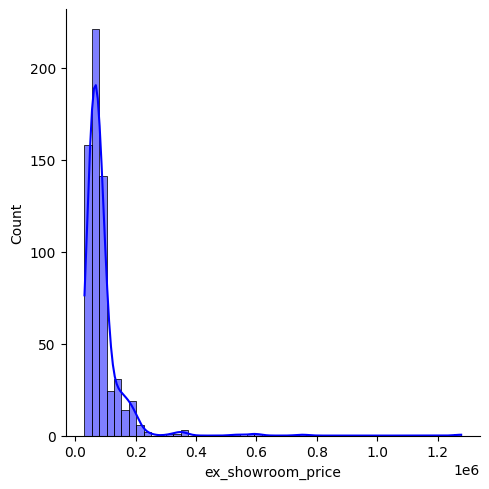

In [109]:
sns.displot(df['ex_showroom_price'], kde=True, color='blue')

In [110]:
df.head()

,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,brand
0,175000,2019,Individual,1st owner,350,NaN,Royal
1,45000,2017,Individual,1st owner,5650,NaN,Honda
2,150000,2018,Individual,1st owner,12000,148114.0,Royal
3,65000,2015,Individual,1st owner,23000,89643.0,Yamaha
4,20000,2011,Individual,2nd owner,21000,NaN,Yamaha


In [111]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import numpy as np

In [112]:
num_features = ['km_driven','ex_showroom_price']
cat_features = ['brand','seller_type']
ord_features = ['owner']

num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="median")),
    ('log',FunctionTransformer(np.log1p))
])

cat_pipeline = Pipeline([
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

ord_pipeline = Pipeline([
    ('ord',OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [113]:
preprocessor = ColumnTransformer([
    ('num',num_pipeline, num_features),
    ('cat',cat_pipeline, cat_features),
    ('ord',ord_pipeline, ord_features)
])

In [114]:
pipeline = Pipeline([
    ('preprocessing',preprocessor),
    ('model',LinearRegression())
])

In [115]:
X = df.drop('selling_price', axis=1)
y = np.log1p(df['selling_price'])

In [116]:
pipeline.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [117]:
import joblib
joblib.dump(pipeline,'bike_price_pipeline.pkl')

['bike_price_pipeline.pkl']